In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def func(x):
    return -0.7 * x - 0.2 * x ** 2 + 0.05 * x ** 3 - 0.2 * np.cos(3 * x) + 2
coord_x = np.arange(-4.0, 6.0, 0.1)
coord_y = func(coord_x)

def model(x, w):
    return x @ w
def df(w, x_batch, y_batch):
    return (2/len(y_batch))*(x_batch.T @ (x_batch@w - y_batch))

sz = len(coord_x)
eta = np.array([0.1, 0.01, 0.001, 0.0001])
w = np.array([0., 0., 0., 0.])
N = 500
lm = 0.02
batch_size = 20
gamma = 0.8
v = np.zeros(len(w))

train_x = np.c_[np.ones_like(coord_x), coord_x, coord_x**2, coord_x**3]
train_y = func(coord_x)

Qe = np.mean((train_x @ w - train_y)**2)

In [3]:
print(f'Qe until training: {Qe}')

Qe until training: 1.9391724730099833


In [4]:
np.random.seed(0)

for _ in range(N):
    k = np.random.randint(0, sz-batch_size-1)
    x_batch, y_batch = train_x[k:k+batch_size], train_y[k:k+batch_size]
    Lk = np.mean((model(x_batch, w) - y_batch)**2)
    Qe = lm*Lk + (1-lm)*Qe
    dQk = df(w - gamma * v, x_batch, y_batch)
    v = gamma * v + (1-gamma) * eta * dQk
    w = w -  v
    
Q = np.mean((train_x @ w - train_y)**2)

In [5]:
print(f'Qe after training: {Qe}')
print(f'w = {w}')
print(f'Q = {Q}')

Qe after training: 0.02158977628558282
w = [ 2.00087266 -0.69417019 -0.1972715   0.04912324]
Q = 0.02023818813679436


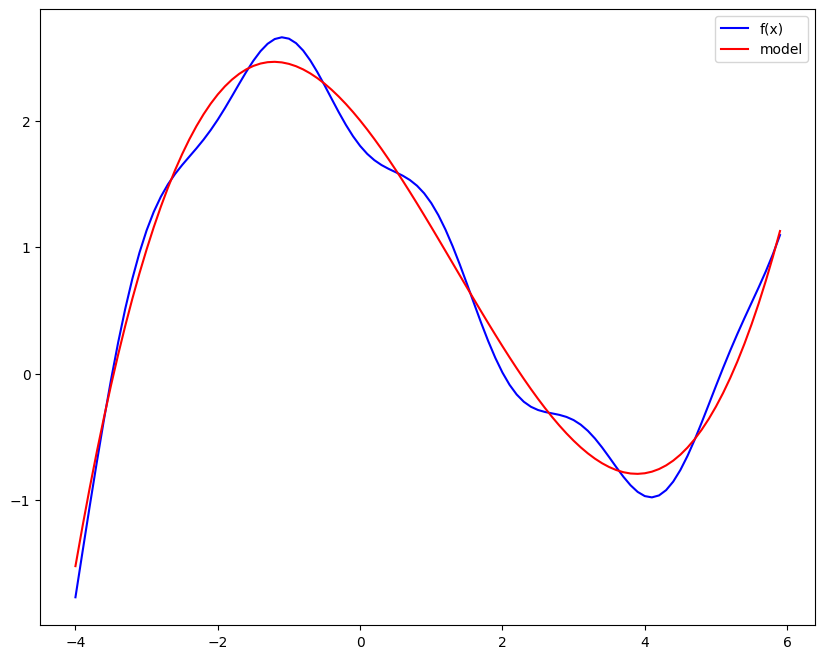

In [6]:
plt.figure(figsize=(10, 8))
plt.plot(coord_x, coord_y, c='blue', label='f(x)')
plt.plot(coord_x, model(train_x, w), c='red', label='model')
plt.legend()
plt.show()